# Leakage-Safe SARIMA / Seasonal AutoARIMA Experiments

- მოდელი ტრეინდება მხოლოდ `train_part`-ზე;
- validation target პროგნოზის შექმნისას არ გამოიყენება;
- `full` რეჟიმში ფასდება validation-ის ყველა მწკრივი, მათ შორის train-ში არნახული სერიებიც;
- სერიები რომლებიც სწავლებისას ვერ ნახა და დაკარგული პროგნოზები ივსება მხოლოდ training data-დან დათვლილი hierarchical fallback-ით;
- notebook ამოწმებს, რომ train-ის ბოლო თარიღი validation-ის პირველ თარიღზე ადრეა;
- `sample` რეჟიმი გამოიყენება მხოლოდ სწრაფი screening-ისთვის, ხოლო საბოლოო შედეგი აღებულია `full` რეჟიმიდან.


## 1. Repository, packages and paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import sys
import subprocess

REPO_URL = "https://github.com/IrakliZerekidze/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting.git"
REPO_DIR = Path("/content/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=True)

os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))

DATA_DIR = REPO_DIR / "data" / "raw"
PROCESSED_DIR = REPO_DIR / "data" / "processed"

print("Working directory:", Path.cwd())


Mounted at /content/drive
Working directory: /content/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting


In [ ]:
!pip install -q statsforecast mlflow dagshub pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.

In [ ]:
DATA_DIR = REPO_DIR / "data" / "raw"
PROCESSED_DIR = REPO_DIR / "data" / "processed"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

required_files = [
    DATA_DIR / "train.csv.zip",
    DATA_DIR / "test.csv.zip",
    DATA_DIR / "features.csv.zip",
    DATA_DIR / "stores.csv",
]

if not all(p.exists() for p in required_files):
    print("Raw Kaggle files not found. Upload kaggle.json when prompted.")
    from google.colab import files
    files.upload()

    Path.home().joinpath(".kaggle").mkdir(exist_ok=True)
    subprocess.run(["cp", "kaggle.json", str(Path.home() / ".kaggle" / "kaggle.json")], check=True)
    subprocess.run(["chmod", "600", str(Path.home() / ".kaggle" / "kaggle.json")], check=True)

    subprocess.run([
        "kaggle", "competitions", "download",
        "-c", "walmart-recruiting-store-sales-forecasting",
        "-p", str(DATA_DIR)
    ], check=True)

    subprocess.run([
        "unzip", "-o",
        str(DATA_DIR / "walmart-recruiting-store-sales-forecasting.zip"),
        "-d", str(DATA_DIR)
    ], check=True)
else:
    print("Raw Kaggle files already exist. Skipping download.")

Raw Kaggle files not found. Upload kaggle.json when prompted.


Saving kaggle.json to kaggle.json


## 2. Load processed data

In [ ]:
import importlib
import preprocessing
importlib.reload(preprocessing)

from preprocessing import run_pipeline, load_processed, weighted_mae

processed_files = [
    PROCESSED_DIR / "train_part.parquet",
    PROCESSED_DIR / "valid_part.parquet",
    PROCESSED_DIR / "train_full.parquet",
    PROCESSED_DIR / "test_full.parquet",
]

FORCE_REPROCESS = False

if FORCE_REPROCESS or not all(path.exists() for path in processed_files):
    print("Running common preprocessing from scratch...")

    for path in processed_files:
        if path.exists():
            path.unlink()

    train_part, valid_part, train_full, test_full = run_pipeline(
        data_dir=DATA_DIR,
        out_dir=PROCESSED_DIR,
        months_valid=3,
        save=True,
    )
else:
    print("Loading existing processed parquet files...")
    train_part, valid_part, train_full, test_full = load_processed(PROCESSED_DIR)

print("train_part:", train_part.shape)
print("valid_part:", valid_part.shape)
print("train_full:", train_full.shape)
print("test_full:", test_full.shape)

print(
    "Validation dates:",
    valid_part["Date"].min(),
    "→",
    valid_part["Date"].max(),
)
print("Validation unique weeks:", valid_part["Date"].nunique())
print("Kaggle test unique weeks:", test_full["Date"].nunique())

Running common preprocessing from scratch...
Expected rows if no gaps: 428409
Actual rows: 380107
Missing (Store,Dept,Date) combos filled in: 48302
Expected rows if no gaps: 476333
Actual rows: 421570
Missing (Store,Dept,Date) combos filled in: 54763
Saved parquet files to /content/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting/data/processed
train_part: (428409, 33)
valid_part: (41463, 32)
train_full: (476333, 33)
test_full: (115064, 29)
Validation dates: 2012-07-27 00:00:00 → 2012-10-26 00:00:00
Validation unique weeks: 14
Kaggle test unique weeks: 39


## 3. Global settings

In [ ]:
GLOBAL_CONFIG = {
    "horizon": int(valid_part["Date"].nunique()),
    "freq": "W-FRI",
    "target_col": "Weekly_Sales",
    "evaluation_target_col": "Weekly_Sales",
    "season_length": 52,
    "n_jobs": -1,
}

METADATA = {
    "model_family": "SARIMA",
    "model_type": "local_univariate_seasonal",
    "missing_target_strategy": "linear_interpolation_train_only",
    "fallback_strategy": "store_dept_then_dept_then_store_then_global_median_train_only",
    "validation_strategy": "last_14_weeks_holdout",
}


RUN_MODE = "full"  # "sample" ან "full"
N_SAMPLE_SERIES = 100
RANDOM_SEED = 42

# დასრულებული run-ების შედეგების ხელახლა გამოყენება.
RESUME_FROM_CSV = False

print(GLOBAL_CONFIG)
print(METADATA)
print("RUN_MODE:", RUN_MODE)


{'horizon': 14, 'freq': 'W-FRI', 'target_col': 'Weekly_Sales', 'evaluation_target_col': 'Weekly_Sales', 'season_length': 52, 'n_jobs': -1}
{'model_family': 'SARIMA', 'model_type': 'local_univariate_seasonal', 'missing_target_strategy': 'linear_interpolation_train_only', 'fallback_strategy': 'store_dept_then_dept_then_store_then_global_median_train_only', 'validation_strategy': 'last_14_weeks_holdout'}
RUN_MODE: full


## 4. Convert to StatsForecast format and select series

In [ ]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple


def fill_missing_target_per_series(
    df: pd.DataFrame,
    target_col: str,
) -> pd.DataFrame:
    """Fill missing historical targets using training data only."""
    result = df.copy()
    result = result.sort_values(["Store", "Dept", "Date"])

    result[target_col] = (
        result.groupby(["Store", "Dept"], group_keys=False)[target_col]
        .apply(
            lambda series: series.interpolate(
                method="linear",
                limit_direction="both",
            )
        )
    )

    result[target_col] = result[target_col].fillna(
        result[target_col].median()
    )
    return result


def add_identifiers(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["unique_id"] = (
        result["Store"].astype(str)
        + "_"
        + result["Dept"].astype(str)
    )
    result["ds"] = pd.to_datetime(result["Date"])
    return result


def make_statsforecast_df(
    df: pd.DataFrame,
    target_col: str,
) -> pd.DataFrame:
    result = fill_missing_target_per_series(df, target_col)
    result = add_identifiers(result)
    result = result.rename(columns={target_col: "y"})

    return (
        result[["unique_id", "ds", "y"]]
        .sort_values(["unique_id", "ds"])
        .reset_index(drop=True)
    )


train_end = pd.to_datetime(train_part["Date"]).max()
valid_start = pd.to_datetime(valid_part["Date"]).min()
valid_end = pd.to_datetime(valid_part["Date"]).max()

assert train_end < valid_start, (
    f"Temporal leakage detected: train_end={train_end}, "
    f"valid_start={valid_start}"
)

train_keys = set(
    zip(
        train_part["Store"],
        train_part["Dept"],
        pd.to_datetime(train_part["Date"]),
    )
)
valid_keys = set(
    zip(
        valid_part["Store"],
        valid_part["Dept"],
        pd.to_datetime(valid_part["Date"]),
    )
)
overlap = train_keys & valid_keys
assert not overlap, (
    f"Train/validation row overlap detected: {len(overlap)} rows"
)

assert valid_part["Date"].nunique() == GLOBAL_CONFIG["horizon"], (
    "Validation horizon does not match CONFIG horizon."
)

print("Leakage audit passed.")
print("Train ends:", train_end)
print("Validation:", valid_start, "→", valid_end)
print("Validation weeks:", valid_part["Date"].nunique())


train_sf_all = make_statsforecast_df(
    train_part,
    target_col=GLOBAL_CONFIG["target_col"],
)

valid_with_ids = add_identifiers(valid_part)

train_ids = set(train_sf_all["unique_id"].unique())
valid_ids = set(valid_with_ids["unique_id"].unique())
common_ids = sorted(train_ids & valid_ids)
unseen_valid_ids = sorted(valid_ids - train_ids)

if RUN_MODE == "sample":
    rng = np.random.default_rng(RANDOM_SEED)
    sampled_ids = sorted(
        rng.choice(
            common_ids,
            size=min(N_SAMPLE_SERIES, len(common_ids)),
            replace=False,
        ).tolist()
    )

    train_sf = train_sf_all[
        train_sf_all["unique_id"].isin(sampled_ids)
    ].copy()

    valid_selected = valid_with_ids[
        valid_with_ids["unique_id"].isin(sampled_ids)
    ].copy()

    evaluation_scope = "sample_seen_series_only"

else:
    train_sf = train_sf_all.copy()
    valid_selected = valid_with_ids.copy()
    sampled_ids = sorted(train_ids)
    evaluation_scope = "full_validation_including_unseen_series"

n_train_series = train_sf["unique_id"].nunique()
n_eval_series = valid_selected["unique_id"].nunique()
n_unseen_eval_series = len(
    set(valid_selected["unique_id"].unique()) - train_ids
)

print("Evaluation scope:", evaluation_scope)
print("Training series:", n_train_series)
print("Validation series:", n_eval_series)
print("Unseen validation series:", n_unseen_eval_series)
print("Training rows:", len(train_sf))
print("Validation rows:", len(valid_selected))


Leakage audit passed.
Train ends: 2012-07-20 00:00:00
Validation: 2012-07-27 00:00:00 → 2012-10-26 00:00:00
Validation weeks: 14
Evaluation scope: full_validation_including_unseen_series
Training series: 3321
Validation series: 3104
Unseen validation series: 10
Training rows: 428409
Validation rows: 41463


## 5. Baseline and evaluation helpers

In [ ]:
def add_hierarchical_fallback(
    eval_df: pd.DataFrame,
    train_df: pd.DataFrame,
    target_col: str,
) -> Tuple[pd.DataFrame, Dict]:
    """Fill missing predictions using statistics computed from train_df only."""
    result = eval_df.copy()

    missing_before = result["pred"].isna()
    missing_rows = int(missing_before.sum())
    unseen_series = int(
        result.loc[missing_before, "unique_id"].nunique()
    )

    store_dept_median = (
        train_df.groupby(["Store", "Dept"])[target_col]
        .median()
        .rename("store_dept_median")
        .reset_index()
    )
    dept_median = (
        train_df.groupby("Dept")[target_col]
        .median()
        .rename("dept_median")
        .reset_index()
    )
    store_median = (
        train_df.groupby("Store")[target_col]
        .median()
        .rename("store_median")
        .reset_index()
    )
    global_median = float(train_df[target_col].median())

    result = result.merge(
        store_dept_median,
        on=["Store", "Dept"],
        how="left",
    )
    result = result.merge(dept_median, on="Dept", how="left")
    result = result.merge(store_median, on="Store", how="left")

    result["pred"] = (
        result["pred"]
        .fillna(result["store_dept_median"])
        .fillna(result["dept_median"])
        .fillna(result["store_median"])
        .fillna(global_median)
    )

    result = result.drop(
        columns=[
            "store_dept_median",
            "dept_median",
            "store_median",
        ]
    )

    assert result["pred"].notna().all(), (
        "Fallback failed: missing predictions remain."
    )

    return result, {
        "missing_prediction_rows_before_fallback": missing_rows,
        "unseen_series_before_fallback": unseen_series,
    }


def compute_metrics(
    eval_df: pd.DataFrame,
    actual_col: str,
    pred_col: str,
) -> Dict[str, float]:
    clean = eval_df.dropna(
        subset=[actual_col, pred_col, "IsHoliday"]
    ).copy()

    assert len(clean) == len(eval_df), (
        "Evaluation contains missing actuals, predictions, or holiday flags."
    )

    overall = weighted_mae(
        clean[actual_col].to_numpy(),
        clean[pred_col].to_numpy(),
        clean["IsHoliday"].to_numpy(),
    )

    holiday = clean[clean["IsHoliday"].astype(bool)]
    nonholiday = clean[~clean["IsHoliday"].astype(bool)]

    holiday_wmae = (
        weighted_mae(
            holiday[actual_col].to_numpy(),
            holiday[pred_col].to_numpy(),
            holiday["IsHoliday"].to_numpy(),
        )
        if len(holiday)
        else np.nan
    )

    nonholiday_wmae = (
        weighted_mae(
            nonholiday[actual_col].to_numpy(),
            nonholiday[pred_col].to_numpy(),
            nonholiday["IsHoliday"].to_numpy(),
        )
        if len(nonholiday)
        else np.nan
    )

    return {
        "wmae": float(overall),
        "holiday_wmae": float(holiday_wmae),
        "nonholiday_wmae": float(nonholiday_wmae),
        "n_eval_rows": int(len(clean)),
    }


def make_store_dept_median_baseline(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    target_col: str,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    medians = (
        train_df.groupby(["Store", "Dept"])[target_col]
        .median()
        .rename("pred")
        .reset_index()
    )

    baseline_eval = valid_df.merge(
        medians,
        on=["Store", "Dept"],
        how="left",
    )

    baseline_eval, fallback_info = add_hierarchical_fallback(
        baseline_eval,
        train_df,
        target_col,
    )

    metrics = compute_metrics(
        baseline_eval,
        actual_col=GLOBAL_CONFIG["evaluation_target_col"],
        pred_col="pred",
    )
    return baseline_eval, {**metrics, **fallback_info}


baseline_eval, baseline_metrics = make_store_dept_median_baseline(
    train_part,
    valid_selected,
    GLOBAL_CONFIG["target_col"],
)

print("Baseline WMAE:", baseline_metrics["wmae"])
print("Baseline holiday WMAE:", baseline_metrics["holiday_wmae"])
print("Baseline non-holiday WMAE:", baseline_metrics["nonholiday_wmae"])
print("Baseline evaluation rows:", baseline_metrics["n_eval_rows"])


Baseline WMAE: 2242.36541498678
Baseline holiday WMAE: 2516.237848954821
Baseline non-holiday WMAE: 2136.862955165337
Baseline evaluation rows: 41463


## 6. Experiment search space

`AutoARIMA` თითოეული Store–Department სერიისთვის ცალკე არჩევს non-seasonal `(p,d,q)` და seasonal `(P,D,Q)` order-ს.

შეზღუდული search spaces runtime-ს ამცირებს. `SeasonalNaive(52)` საჭიროა იმის შესამოწმებლად, საერთოდ რამდენად სასარგებლოა წლიური სეზონურობა.


In [ ]:
EXPERIMENTS = [
    {
        "name": "seasonal_naive_52",
        "model": "SeasonalNaive",
        "description": "Previous-year same-week baseline",
        "season_length": 52,
    },
    {
        "name": "autoarima_nonseasonal_fast",
        "model": "AutoARIMA",
        "description": "Fast non-seasonal automatic ARIMA",
        "season_length": 1,
        "stepwise": True,
        "approximation": True,
        "max_p": 3,
        "max_q": 3,
        "max_P": 0,
        "max_Q": 0,
        "max_order": 5,
        "max_d": 1,
        "max_D": 0,
    },
    {
        "name": "autoarima_s52_small",
        "model": "AutoARIMA",
        "description": "Small seasonal SARIMA search space",
        "season_length": 52,
        "stepwise": True,
        "approximation": True,
        "max_p": 2,
        "max_q": 2,
        "max_P": 1,
        "max_Q": 1,
        "max_order": 4,
        "max_d": 1,
        "max_D": 1,
    },
    {
        "name": "autoarima_s52_medium",
        "model": "AutoARIMA",
        "description": "Wider seasonal SARIMA search space",
        "season_length": 52,
        "stepwise": True,
        "approximation": True,
        "max_p": 3,
        "max_q": 3,
        "max_P": 1,
        "max_Q": 1,
        "max_order": 6,
        "max_d": 1,
        "max_D": 1,
    },
    {
        "name": "autoarima_s52_D0",
        "model": "AutoARIMA",
        "description": "Seasonal AR/MA terms without seasonal differencing",
        "season_length": 52,
        "stepwise": True,
        "approximation": True,
        "D": 0,
        "max_p": 3,
        "max_q": 3,
        "max_P": 1,
        "max_Q": 1,
        "max_order": 6,
        "max_d": 1,
        "max_D": 0,
    },
    {
        "name": "autoarima_s52_D1",
        "model": "AutoARIMA",
        "description": "Force one seasonal difference",
        "season_length": 52,
        "stepwise": True,
        "approximation": True,
        "D": 1,
        "max_p": 2,
        "max_q": 2,
        "max_P": 1,
        "max_Q": 1,
        "max_order": 4,
        "max_d": 1,
        "max_D": 1,
    },
]

# RUN_ONLY = None
RUN_ONLY = {
    "autoarima_s52_D1",
    "autoarima_s52_small",
    "autoarima_s52_medium",
}

if RUN_ONLY is not None:
    EXPERIMENTS = [
        exp for exp in EXPERIMENTS
        if exp["name"] in RUN_ONLY
    ]

pd.DataFrame(EXPERIMENTS)


,name,model,description,season_length,stepwise,approximation,max_p,max_q,max_P,max_Q,max_order,max_d,max_D,D
0,autoarima_s52_small,AutoARIMA,Small seasonal SARIMA search space,52,True,True,2,2,1,1,4,1,1,NaN
1,autoarima_s52_medium,AutoARIMA,Wider seasonal SARIMA search space,52,True,True,3,3,1,1,6,1,1,NaN
2,autoarima_s52_D1,AutoARIMA,Force one seasonal difference,52,True,True,2,2,1,1,4,1,1,1.0


## 7. MLflow / DagsHub setup

In [ ]:
import dagshub
import mlflow

dagshub.init(
    repo_owner="izere23",
    repo_name="ML-Final-Walmart-Recruiting-Store-Sales-Forecasting",
    mlflow=True,
)

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_experiment("SARIMA_Training")

print("Tracking URI:", mlflow.get_tracking_uri())


Initialized MLflow to track repo "izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting"

Repository izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting initialized!

Tracking URI: https://dagshub.com/izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting.mlflow


## 8. Run all experiments, evaluate and log

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, SeasonalNaive
import inspect
import time
import traceback
import json
import warnings

warnings.filterwarnings(
    "ignore",
    message="possible convergence problem*",
)

ARTIFACT_ROOT = REPO_DIR / "artifacts" / "sarima_leakage_safe"
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = ARTIFACT_ROOT / f"results_{RUN_MODE}.csv"


def supported_kwargs(model_class, params: Dict) -> Dict:
    signature = inspect.signature(model_class.__init__)
    valid_names = set(signature.parameters)
    return {
        key: value
        for key, value in params.items()
        if key in valid_names
    }


def build_model(exp: Dict):
    alias = exp["name"]

    if exp["model"] == "SeasonalNaive":
        return SeasonalNaive(
            season_length=exp["season_length"],
            alias=alias,
        )

    if exp["model"] == "AutoARIMA":
        raw_kwargs = {
            key: value
            for key, value in exp.items()
            if key not in {"name", "model", "description"}
        }
        raw_kwargs["alias"] = alias
        kwargs = supported_kwargs(AutoARIMA, raw_kwargs)

        ignored = sorted(set(raw_kwargs) - set(kwargs))
        if ignored:
            print(f"{alias}: ignored unsupported parameters:", ignored)

        return AutoARIMA(**kwargs)

    raise ValueError(f"Unknown model type: {exp['model']}")


def evaluate_forecast(
    forecast_df: pd.DataFrame,
    experiment_name: str,
):
    pred_candidates = [
        column
        for column in forecast_df.columns
        if column not in {"unique_id", "ds"}
    ]

    if experiment_name in forecast_df.columns:
        pred_col = experiment_name
    elif len(pred_candidates) == 1:
        pred_col = pred_candidates[0]
    else:
        raise ValueError(
            "Could not identify prediction column: "
            f"{forecast_df.columns.tolist()}"
        )

    predictions = (
        forecast_df[["unique_id", "ds", pred_col]]
        .rename(columns={pred_col: "pred"})
        .copy()
    )
    counts = predictions.groupby("unique_id").size()
    if not counts.empty:
        assert counts.eq(GLOBAL_CONFIG["horizon"]).all(), (
            "At least one forecasted series does not have the expected horizon."
        )
    eval_df = valid_selected.merge(
        predictions,
        on=["unique_id", "ds"],
        how="left",
        validate="one_to_one",
    )

    assert len(eval_df) == len(valid_selected), (
        "Evaluation merge changed the number of validation rows."
    )

    eval_df, fallback_info = add_hierarchical_fallback(
        eval_df,
        train_part,
        GLOBAL_CONFIG["target_col"],
    )

    metrics = compute_metrics(
        eval_df,
        actual_col=GLOBAL_CONFIG["evaluation_target_col"],
        pred_col="pred",
    )

    return predictions, eval_df, metrics, fallback_info


if RESUME_FROM_CSV and RESULTS_CSV.exists():
    previous_results = pd.read_csv(RESULTS_CSV)
    completed_names = set(
        previous_results.loc[
            previous_results["status"] == "finished",
            "experiment",
        ]
    )
    all_results = previous_results.to_dict("records")
else:
    completed_names = set()
    all_results = []


for exp in EXPERIMENTS:
    name = exp["name"]

    if name in completed_names:
        print(f"Skipping already completed run: {name}")
        continue

    print("\n" + "=" * 80)
    print("Running:", name)
    print("Evaluation scope:", evaluation_scope)
    print(exp)
    print("=" * 80)

    run_name = (
        f"{name}"
        f"_{RUN_MODE}"
        f"_train{n_train_series}"
        f"_eval{n_eval_series}"
        f"_h{GLOBAL_CONFIG['horizon']}"
    )

    artifact_dir = ARTIFACT_ROOT / run_name
    artifact_dir.mkdir(parents=True, exist_ok=True)

    start = time.perf_counter()

    try:
        model = build_model(exp)

        sf = StatsForecast(
            models=[model],
            freq=GLOBAL_CONFIG["freq"],
            n_jobs=GLOBAL_CONFIG["n_jobs"],
        )
        forecast_df = sf.forecast(
            df=train_sf,
            h=GLOBAL_CONFIG["horizon"],
        )

        training_seconds = time.perf_counter() - start

        (
            predictions,
            valid_eval,
            metrics,
            fallback_info,
        ) = evaluate_forecast(
            forecast_df,
            experiment_name=name,
        )

        improvement = baseline_metrics["wmae"] - metrics["wmae"]
        improvement_pct = (
            improvement / baseline_metrics["wmae"] * 100
        )

        row = {
            "experiment": name,
            "model": exp["model"],
            "description": exp["description"],
            "run_mode": RUN_MODE,
            "evaluation_scope": evaluation_scope,
            "n_train_series": n_train_series,
            "n_eval_series": n_eval_series,
            "n_unseen_eval_series": n_unseen_eval_series,
            "n_eval_rows": metrics["n_eval_rows"],
            "train_end": str(train_end.date()),
            "valid_start": str(valid_start.date()),
            "valid_end": str(valid_end.date()),
            "season_length": exp["season_length"],
            "valid_wmae": metrics["wmae"],
            "holiday_wmae": metrics["holiday_wmae"],
            "nonholiday_wmae": metrics["nonholiday_wmae"],
            "baseline_wmae": baseline_metrics["wmae"],
            "improvement": improvement,
            "improvement_pct": improvement_pct,
            "training_seconds": training_seconds,
            **fallback_info,
            "status": "finished",
            "error": "",
        }

        predictions.to_csv(
            artifact_dir / "valid_predictions.csv",
            index=False,
        )
        valid_eval.to_csv(
            artifact_dir / "valid_eval.csv",
            index=False,
        )

        with open(
            artifact_dir / "experiment_config.json",
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(exp, file, ensure_ascii=False, indent=2)

        with open(
            artifact_dir / "metrics.json",
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(row, file, ensure_ascii=False, indent=2)

        with mlflow.start_run(run_name=run_name):
            mlflow.log_param("model", exp["model"])
            mlflow.log_param("model_family", METADATA["model_family"])
            mlflow.log_param("model_type", METADATA["model_type"])
            mlflow.log_param("description", exp["description"])
            mlflow.log_param("run_mode", RUN_MODE)
            mlflow.log_param("evaluation_scope", evaluation_scope)
            mlflow.log_param("n_train_series", n_train_series)
            mlflow.log_param("n_eval_series", n_eval_series)
            mlflow.log_param(
                "n_unseen_eval_series",
                n_unseen_eval_series,
            )
            mlflow.log_param("horizon", GLOBAL_CONFIG["horizon"])
            mlflow.log_param("freq", GLOBAL_CONFIG["freq"])
            mlflow.log_param(
                "target_col",
                GLOBAL_CONFIG["target_col"],
            )
            mlflow.log_param(
                "season_length",
                exp["season_length"],
            )
            mlflow.log_param(
                "missing_target_strategy",
                METADATA["missing_target_strategy"],
            )
            mlflow.log_param(
                "fallback_strategy",
                METADATA["fallback_strategy"],
            )
            mlflow.log_param(
                "validation_strategy",
                METADATA["validation_strategy"],
            )
            mlflow.log_param("train_end", str(train_end.date()))
            mlflow.log_param("valid_start", str(valid_start.date()))
            mlflow.log_param("valid_end", str(valid_end.date()))

            for key, value in exp.items():
                if key not in {
                    "name",
                    "model",
                    "description",
                    "season_length",
                }:
                    mlflow.log_param(key, value)

            mlflow.log_metric(
                "baseline_store_dept_median_wmae",
                baseline_metrics["wmae"],
            )
            mlflow.log_metric("valid_wmae", metrics["wmae"])
            mlflow.log_metric(
                "holiday_wmae",
                metrics["holiday_wmae"],
            )
            mlflow.log_metric(
                "nonholiday_wmae",
                metrics["nonholiday_wmae"],
            )
            mlflow.log_metric(
                "improvement_over_baseline",
                improvement,
            )
            mlflow.log_metric(
                "improvement_over_baseline_pct",
                improvement_pct,
            )
            mlflow.log_metric(
                "training_seconds",
                training_seconds,
            )
            mlflow.log_metric(
                "n_eval_rows",
                metrics["n_eval_rows"],
            )
            mlflow.log_metric(
                "missing_prediction_rows_before_fallback",
                fallback_info[
                    "missing_prediction_rows_before_fallback"
                ],
            )
            mlflow.log_metric(
                "unseen_series_before_fallback",
                fallback_info[
                    "unseen_series_before_fallback"
                ],
            )

            mlflow.log_artifacts(str(artifact_dir))

        print(
            f"{name}: WMAE={metrics['wmae']:.4f}, "
            f"holiday={metrics['holiday_wmae']:.4f}, "
            f"improvement={improvement_pct:.2f}%, "
            f"rows={metrics['n_eval_rows']}, "
            f"time={training_seconds:.1f}s"
        )

    except Exception as exc:
        training_seconds = time.perf_counter() - start
        error_text = f"{type(exc).__name__}: {exc}"

        row = {
            "experiment": name,
            "model": exp["model"],
            "description": exp["description"],
            "run_mode": RUN_MODE,
            "evaluation_scope": evaluation_scope,
            "n_train_series": n_train_series,
            "n_eval_series": n_eval_series,
            "n_unseen_eval_series": n_unseen_eval_series,
            "n_eval_rows": np.nan,
            "train_end": str(train_end.date()),
            "valid_start": str(valid_start.date()),
            "valid_end": str(valid_end.date()),
            "season_length": exp["season_length"],
            "valid_wmae": np.nan,
            "holiday_wmae": np.nan,
            "nonholiday_wmae": np.nan,
            "baseline_wmae": baseline_metrics["wmae"],
            "improvement": np.nan,
            "improvement_pct": np.nan,
            "training_seconds": training_seconds,
            "missing_prediction_rows_before_fallback": np.nan,
            "unseen_series_before_fallback": np.nan,
            "status": "failed",
            "error": error_text,
        }

        print("FAILED:", error_text)
        traceback.print_exc()

        with mlflow.start_run(run_name=run_name):
            mlflow.log_param("model", exp["model"])
            mlflow.log_param("description", exp["description"])
            mlflow.log_param("run_mode", RUN_MODE)
            mlflow.log_param("evaluation_scope", evaluation_scope)
            mlflow.log_param("status", "failed")
            mlflow.log_param("error", error_text[:500])
            mlflow.log_metric(
                "training_seconds",
                training_seconds,
            )

    all_results.append(row)

    results_df = pd.DataFrame(all_results)
    results_df = results_df.drop_duplicates(
        subset=["experiment", "run_mode", "evaluation_scope"],
        keep="last",
    )
    results_df.to_csv(RESULTS_CSV, index=False)

print("\nAll requested runs finished.")



Running: autoarima_s52_small
Evaluation scope: full_validation_including_unseen_series
{'name': 'autoarima_s52_small', 'model': 'AutoARIMA', 'description': 'Small seasonal SARIMA search space', 'season_length': 52, 'stepwise': True, 'approximation': True, 'max_p': 2, 'max_q': 2, 'max_P': 1, 'max_Q': 1, 'max_order': 4, 'max_d': 1, 'max_D': 1}
🏃 View run autoarima_s52_small_full_train3321_eval3104_h14 at: https://dagshub.com/izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting.mlflow/#/experiments/6/runs/eef3a7b71da14b4b82f6f17ebbb2ba72
🧪 View experiment at: https://dagshub.com/izere23/ML-Final-Walmart-Recruiting-Store-Sales-Forecasting.mlflow/#/experiments/6
autoarima_s52_small: WMAE=1450.8352, holiday=1444.4723, improvement=35.30%, rows=41463, time=731.5s

Running: autoarima_s52_medium
Evaluation scope: full_validation_including_unseen_series
{'name': 'autoarima_s52_medium', 'model': 'AutoARIMA', 'description': 'Wider seasonal SARIMA search space', 'season_length': 52, 'stepwis

## 9. Compare experiments

In [ ]:
results_df = pd.read_csv(RESULTS_CSV)

leaderboard = (
    results_df[results_df["status"] == "finished"]
    .sort_values("valid_wmae")
    .reset_index(drop=True)
)

display(
    leaderboard[
        [
            "experiment",
            "model",
            "run_mode",
            "evaluation_scope",
            "n_train_series",
            "n_eval_series",
            "n_unseen_eval_series",
            "n_eval_rows",
            "valid_wmae",
            "holiday_wmae",
            "nonholiday_wmae",
            "improvement_pct",
            "training_seconds",
        ]
    ]
)

if len(leaderboard):
    best = leaderboard.iloc[0]
    print("\nBest experiment:", best["experiment"])
    print("Best valid WMAE:", best["valid_wmae"])
    print("Evaluation scope:", best["evaluation_scope"])
    print("Evaluation rows:", best["n_eval_rows"])

    if best["run_mode"] == "sample":
        print(
            "\nWARNING: This is a screening result on sampled seen series. "
            "Run the selected model in full mode before reporting it."
        )


,experiment,model,run_mode,evaluation_scope,n_train_series,n_eval_series,n_unseen_eval_series,n_eval_rows,valid_wmae,holiday_wmae,nonholiday_wmae,improvement_pct,training_seconds
0,autoarima_s52_small,AutoARIMA,full,full_validation_including_unseen_series,3321,3104,10,41463,1450.835235,1444.472337,1453.286381,35.298894,731.469538
1,autoarima_s52_medium,AutoARIMA,full,full_validation_including_unseen_series,3321,3104,10,41463,1452.720808,1448.844604,1454.214017,35.214805,816.362455
2,autoarima_s52_D1,AutoARIMA,full,full_validation_including_unseen_series,3321,3104,10,41463,1499.822616,1482.311125,1506.568477,33.114264,751.493949



Best experiment: autoarima_s52_small
Best valid WMAE: 1450.8352350001876
Evaluation scope: full_validation_including_unseen_series
Evaluation rows: 41463


## 10. Plot the best experiment

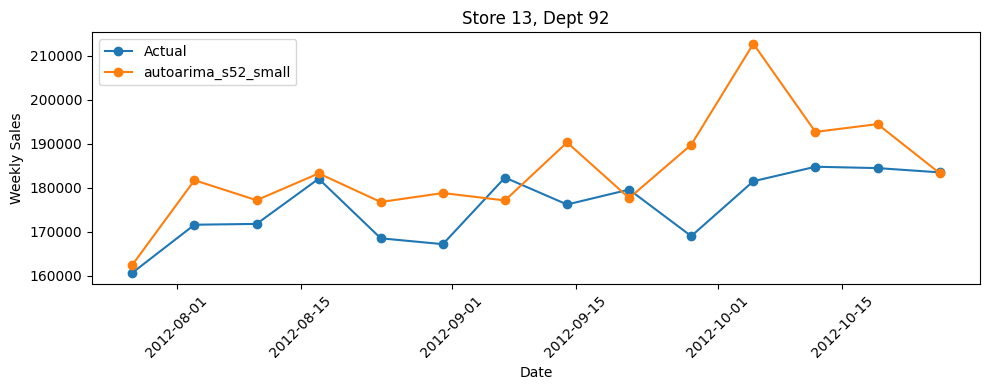

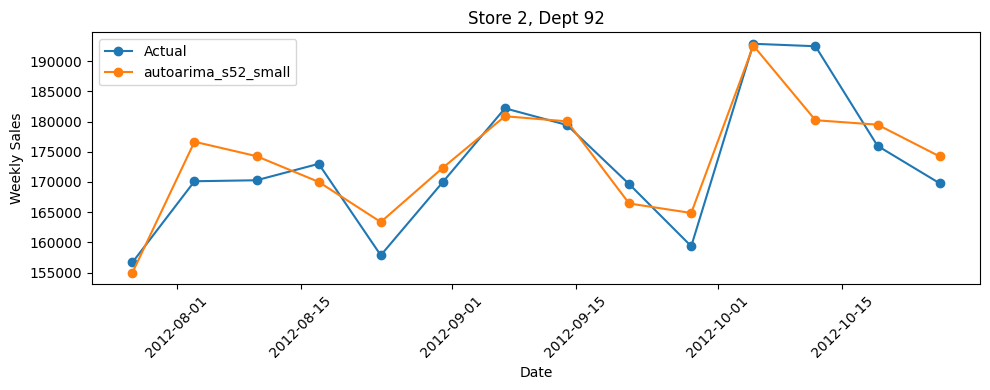

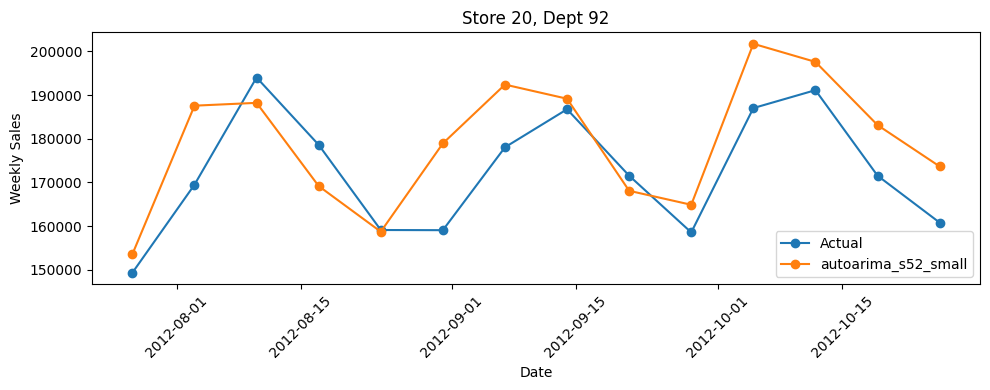

In [ ]:
import matplotlib.pyplot as plt

if len(leaderboard):
    best_name = leaderboard.iloc[0]["experiment"]
    best_run_name = (
        f"{best_name}_{RUN_MODE}"
        f"_train{n_train_series}"
        f"_eval{n_eval_series}"
        f"_h{GLOBAL_CONFIG['horizon']}"
    )
    best_eval_path = (
        ARTIFACT_ROOT
        / best_run_name
        / "valid_eval.csv"
    )

    best_eval = pd.read_csv(
        best_eval_path,
        parse_dates=["Date", "ds"],
    )

    top_pairs = (
        best_eval.groupby(["Store", "Dept"])[
            GLOBAL_CONFIG["evaluation_target_col"]
        ]
        .sum()
        .sort_values(ascending=False)
        .head(3)
        .index
        .tolist()
    )

    for store, dept in top_pairs:
        plot_df = best_eval[
            (best_eval["Store"] == store)
            & (best_eval["Dept"] == dept)
        ].sort_values("Date")

        plt.figure(figsize=(10, 4))
        plt.plot(
            plot_df["Date"],
            plot_df[GLOBAL_CONFIG["evaluation_target_col"]],
            marker="o",
            label="Actual",
        )
        plt.plot(
            plot_df["Date"],
            plot_df["pred"],
            marker="o",
            label=best_name,
        )
        plt.title(f"Store {store}, Dept {dept}")
        plt.xlabel("Date")
        plt.ylabel("Weekly Sales")
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
